# EDA и эксперименты: Jira issue delay risk

Ноутбук выполняет разведочный анализ реального Jira export, показывает предобработку, построение целевой переменной, графики и результаты экспериментов.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..')
RAW_PATH = PROJECT_ROOT / 'data' / 'jira_dataset.csv'
PREPARED_PATH = PROJECT_ROOT / 'artifacts' / 'jira_issues_prepared.csv'
LEADERBOARD_PATH = PROJECT_ROOT / 'artifacts' / 'leaderboard.json'

raw_columns = ['Issue key', 'Issue Type', 'Priority', 'Created', 'Resolved', 'Component/s', 'Summary', 'Description']
raw = pd.read_csv(RAW_PATH, usecols=lambda c: c in raw_columns)
raw.shape

(49000, 8)

## Предобработка данных

Шаги: парсинг дат `Created` и `Resolved`, удаление строк без валидного закрытия, расчет `resolution_time_days`, построение `is_delayed` по 75-му процентилю, заполнение пропусков в `Priority`, выделение признаков длины текста и числа слов.

In [2]:
raw['Created'] = pd.to_datetime(raw['Created'], format='%d/%b/%Y %I:%M %p', errors='coerce')
raw['Resolved'] = pd.to_datetime(raw['Resolved'], format='%d/%b/%Y %I:%M %p', errors='coerce')
resolved = raw.dropna(subset=['Created', 'Resolved']).copy()
resolved['resolution_time_days'] = (resolved['Resolved'] - resolved['Created']).dt.total_seconds() / 86400
resolved = resolved[resolved['resolution_time_days'] >= 0].copy()
threshold = resolved['resolution_time_days'].quantile(0.75)
resolved['is_delayed'] = (resolved['resolution_time_days'] > threshold).astype(int)

summary = resolved['Summary'].fillna('').astype(str)
description = resolved['Description'].fillna('').astype(str)
priority = resolved['Priority'].fillna('Unknown').astype(str)
component = resolved['Component/s'].fillna('').astype(str).str.strip()

prepared = pd.DataFrame({
    'issue_key': resolved['Issue key'].astype(str),
    'issue_type': resolved['Issue Type'].fillna('Unknown').astype(str),
    'priority': priority,
    'has_priority': (priority != 'Unknown').astype(int),
    'component_present': (component != '').astype(int),
    'summary_length': summary.str.len(),
    'summary_word_count': summary.str.split().str.len(),
    'description_length': description.str.len(),
    'description_word_count': description.str.split().str.len(),
    'resolution_time_days': resolved['resolution_time_days'],
    'is_delayed': resolved['is_delayed'],
})
prepared.shape, round(threshold, 4)

((16562, 11), 305.2056)

## Пропуски и качество исходных полей

График ниже строится по выбранным исходным Jira-полям. Поле `Resolved` пропущено у открытых или незакрытых задач, поэтому для supervised-обучения берутся только валидно закрытые issues.

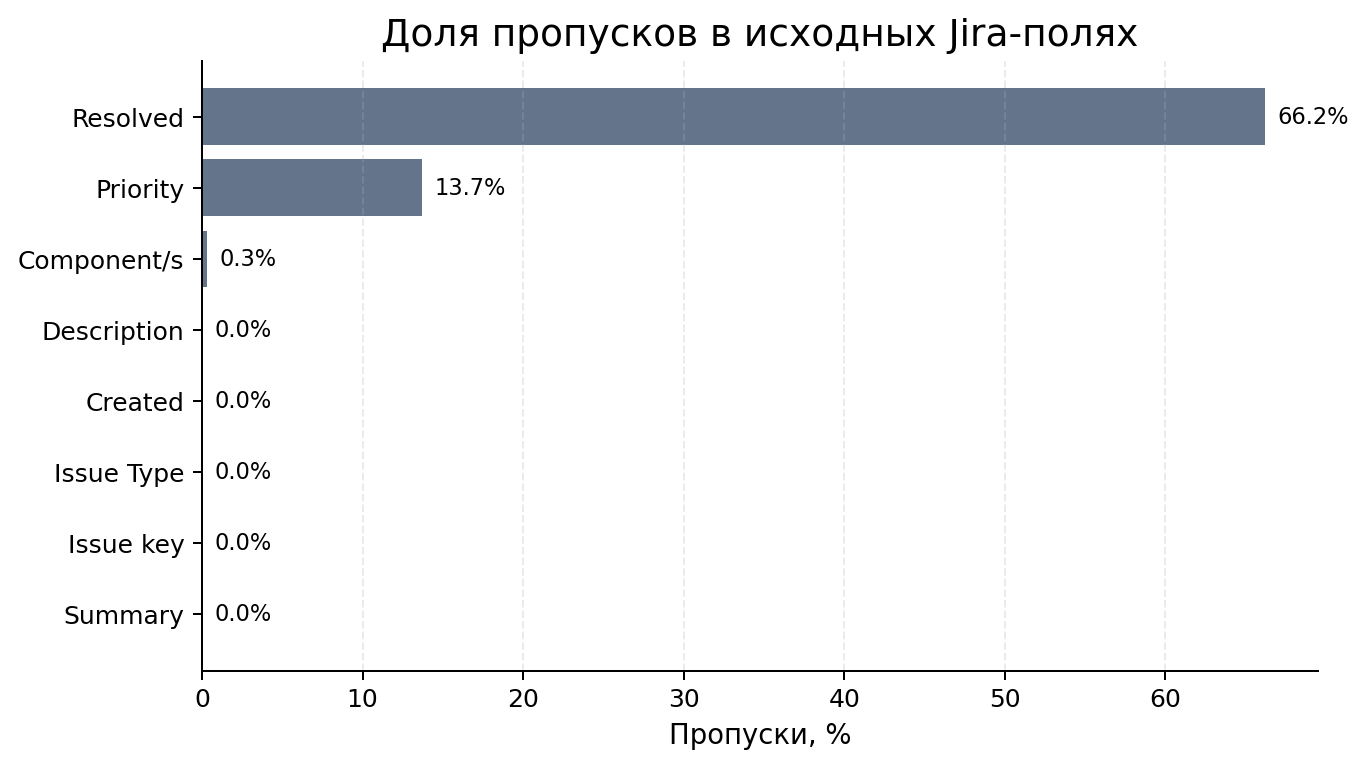

In [3]:
missing = raw[raw_columns].isna().mean().sort_values(ascending=True) * 100
ax = missing.plot(kind='barh', figsize=(8, 4.4), color='#64748b')
ax.set_title('Доля пропусков в исходных Jira-полях')
ax.set_xlabel('Пропуски, %')
ax.grid(axis='x', alpha=.25, linestyle='--')
plt.show()

## Распределение целевой переменной

Класс `is_delayed = 1` означает, что issue закрывалась дольше 75-го процентиля по `resolution_time_days`.

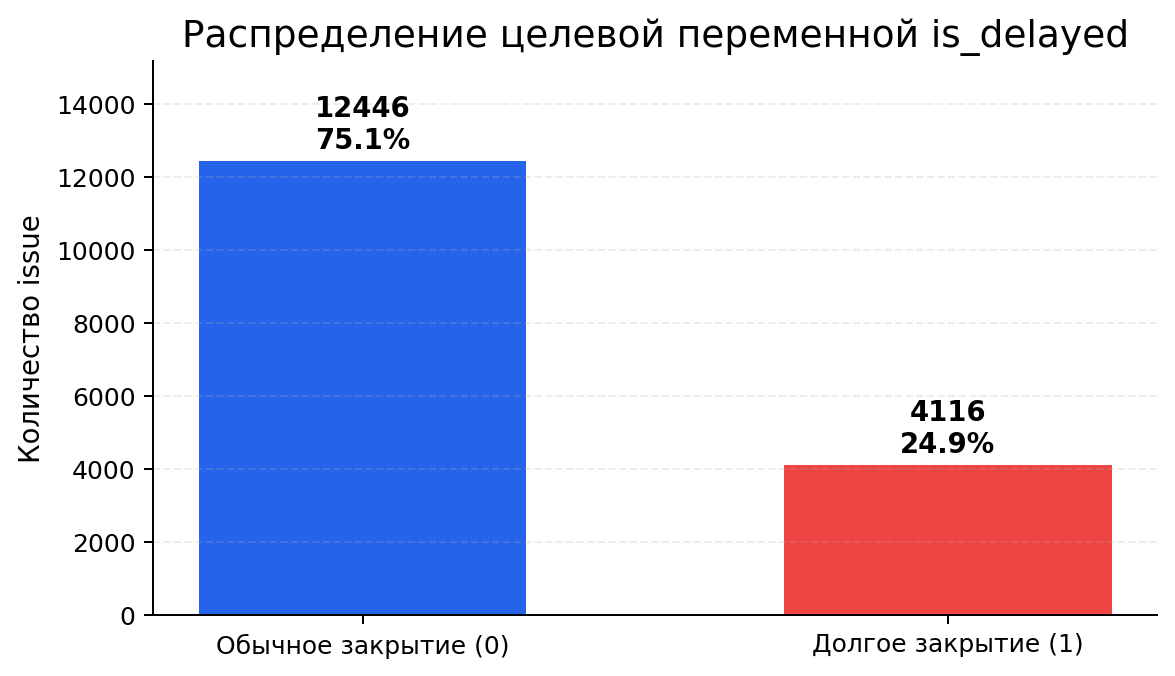

In [4]:
counts = prepared['is_delayed'].value_counts().sort_index()
ax = counts.plot(kind='bar', figsize=(7.2, 4.0), color=['#2563eb', '#ef4444'])
ax.set_xticklabels(['Обычное закрытие (0)', 'Долгое закрытие (1)'], rotation=0)
ax.set_title('Распределение целевой переменной is_delayed')
ax.set_ylabel('Количество issue')
ax.grid(axis='y', alpha=.22, linestyle='--')
plt.show()

## Выбросы и длинный хвост времени закрытия

Время закрытия имеет длинный хвост, поэтому на графике значения обрезаны сверху на 900 дней только для читаемости визуализации. В расчетах используется исходное значение.

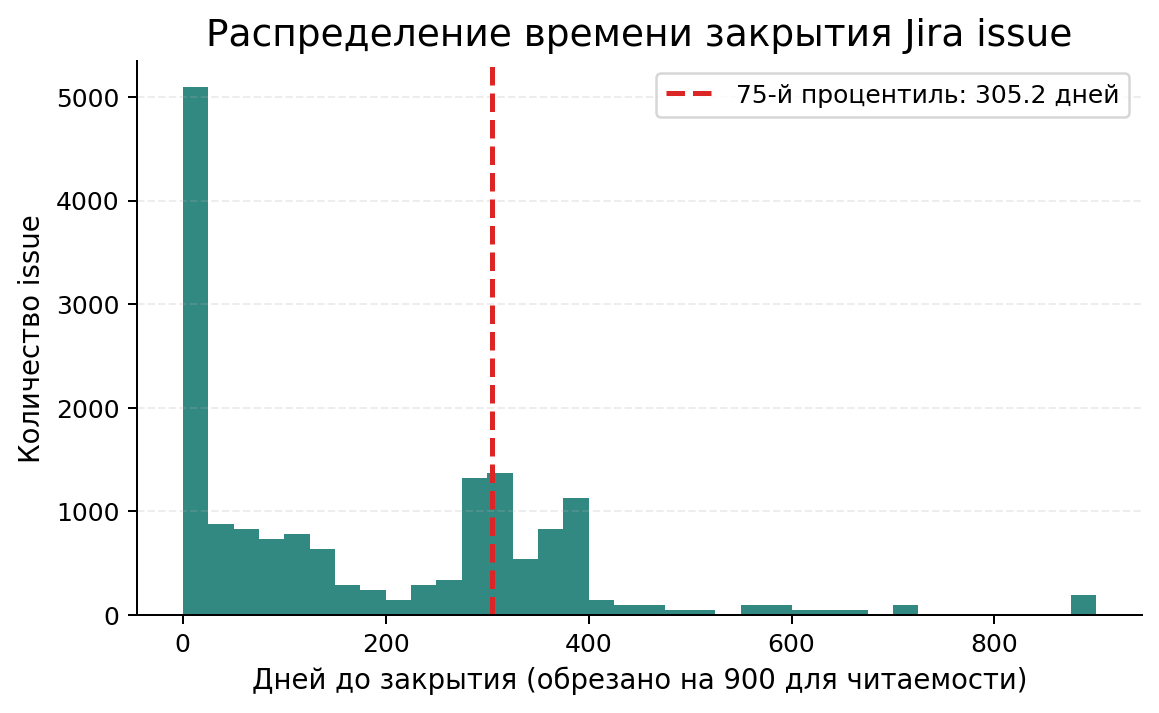

In [5]:
ax = prepared['resolution_time_days'].clip(upper=900).plot(kind='hist', bins=36, figsize=(7.2, 4.0), color='#0f766e')
ax.axvline(threshold, color='#dc2626', lw=2, ls='--', label=f'75-й процентиль: {threshold:.1f} дней')
ax.set_title('Распределение времени закрытия Jira issue')
ax.set_xlabel('Дней до закрытия')
ax.legend()
plt.show()

## Признаки без утечки данных

В модель не передаются `Status`, `Resolution`, `Resolved`, `Updated` и `resolution_time_days`. Нормализация числовых признаков и one-hot encoding категориальных признаков выполняются в `src/train.py` через `ColumnTransformer`: `SimpleImputer + StandardScaler` для числовых полей и `SimpleImputer + OneHotEncoder` для категориальных.

In [6]:
feature_columns = [
    'issue_type', 'priority', 'has_priority', 'component_present',
    'summary_length', 'summary_word_count',
    'description_length', 'description_word_count',
]
prepared[feature_columns + ['is_delayed']].head()

   issue_type priority  has_priority  component_present  summary_length  summary_word_count  description_length  description_word_count  is_delayed
0         Bug      Low             1                  1              59                   9                 269                      52           0
1         Bug      Low             1                  1              59                   9                 269                      52           0
2  Suggestion  Unknown             0                  1              16                   2               20401                    2700           0
3         Bug     High             1                  1              46                   6                1869                      90           0
4         Bug     High             1                  1              40                   7                1817                      90           0

## Результаты экспериментов

Метрики берутся из `artifacts/leaderboard.json`, который формируется командой `python -m src.train`.

In [7]:
leaderboard = pd.read_json(LEADERBOARD_PATH).T
leaderboard

                     accuracy  precision  recall      f1  roc_auc
logistic_regression    0.5083     0.3112  0.8068  0.4491   0.6436
random_forest          0.6933     0.4465  0.9781  0.6131   0.9198
gradient_boosting      0.7972     0.9364  0.1968  0.3253   0.8960

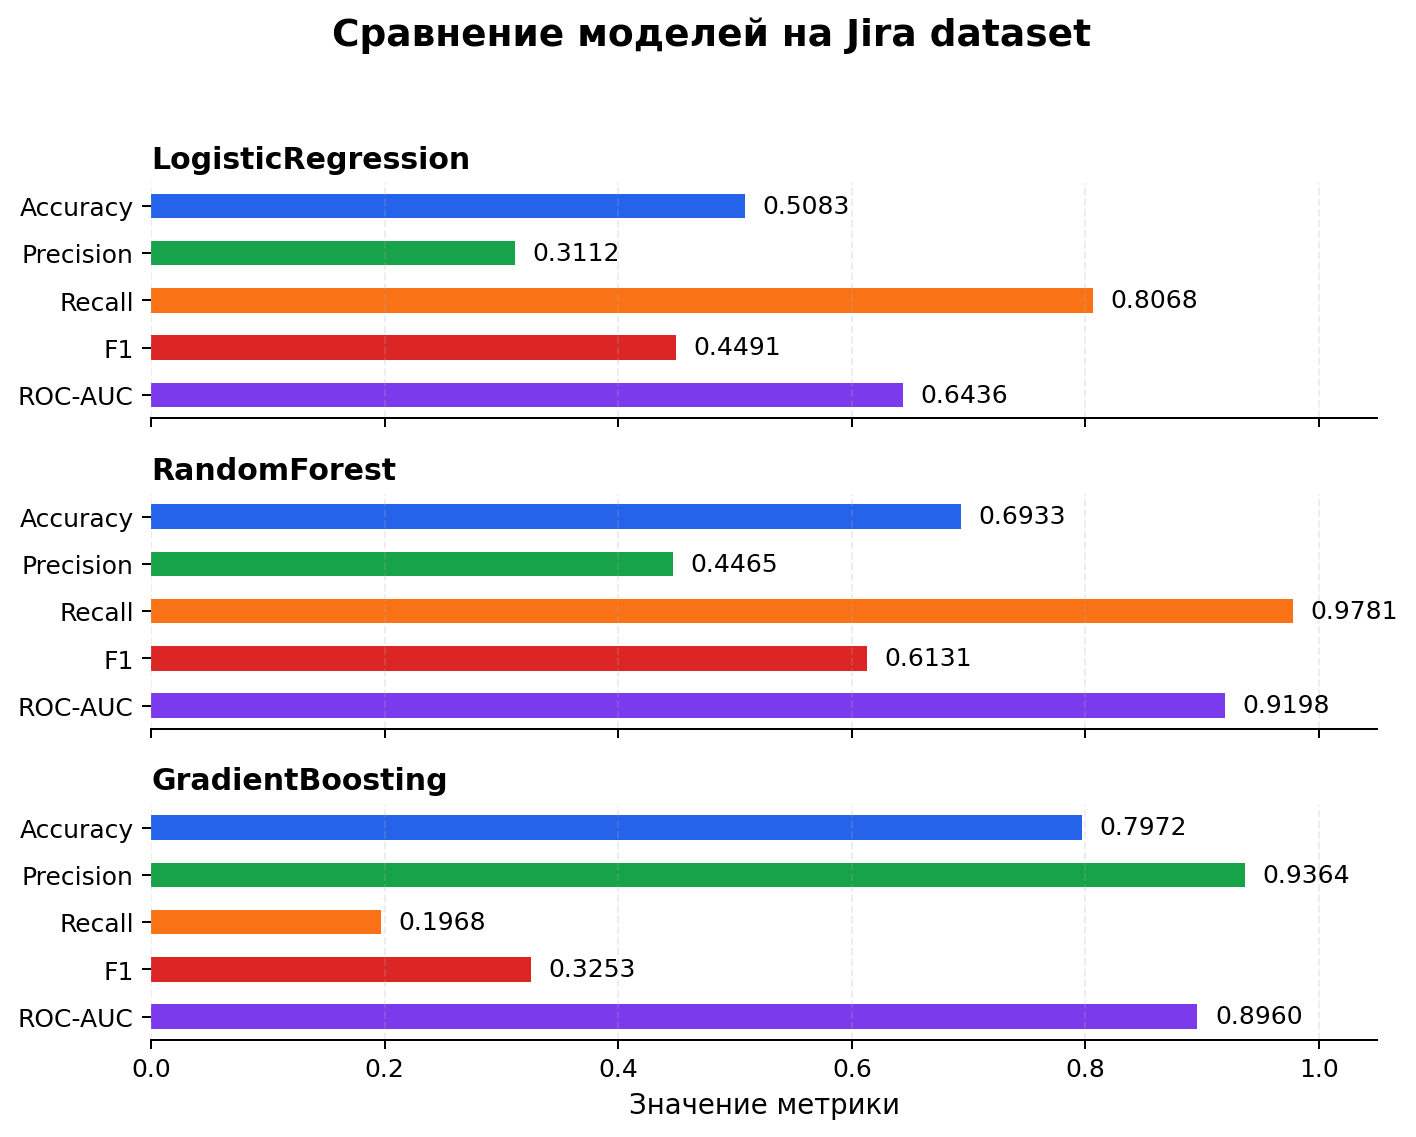

In [8]:
# Визуальное сравнение моделей по метрикам
# RandomForest выбран финальной моделью по F1 и Recall.
leaderboard[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]